In [2]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/movie_dataset')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os

print(os.listdir('/content/movie_dataset'))

['Genre Classification Dataset']


In [ ]:
import os

print(os.listdir('/content/movie_dataset/Genre Classification Dataset'))

In [5]:
import os

print(os.listdir('/content/movie_dataset/Genre Classification Dataset'))

['test_data_solution.txt', 'test_data.txt', 'train_data.txt', 'description.txt']


In [6]:
import pandas as pd

train_path = '/content/movie_dataset/Genre Classification Dataset/train_data.txt'

df = pd.read_csv(
    train_path,
    sep=':::',
    engine='python',
    header=None,
    names=['ID', 'TITLE', 'GENRE', 'DESCRIPTION']
)

print(df.head())

   ID                               TITLE       GENRE  \
0   1       Oscar et la dame rose (2009)       drama    
1   2                       Cupid (1997)    thriller    
2   3   Young, Wild and Wonderful (1980)       adult    
3   4              The Secret Sin (1915)       drama    
4   5             The Unrecovered (2007)       drama    

                                         DESCRIPTION  
0   Listening in to a conversation between his do...  
1   A brother and sister with a past incestuous r...  
2   As the bus empties the students for their fie...  
3   To help their unemployed father make ends mee...  
4   The film's title refers not only to the un-re...  


In [7]:
print("Total Movies:", len(df))
print("\nNumber of Genres:", df['GENRE'].nunique())
print("\nGenres:")
print(df['GENRE'].value_counts())

Total Movies: 54214

Number of Genres: 27

Genres:
GENRE
drama           13613
documentary     13096
comedy           7447
short            5073
horror           2204
thriller         1591
action           1315
western          1032
reality-tv        884
family            784
adventure         775
music             731
romance           672
sci-fi            647
adult             590
crime             505
animation         498
sport             432
talk-show         391
fantasy           323
mystery           319
musical           277
biography         265
history           243
game-show         194
news              181
war               132
Name: count, dtype: int64


In [8]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
ID             0
TITLE          0
GENRE          0
DESCRIPTION    0
dtype: int64


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (54214, 4)


In [11]:
df['DESCRIPTION'] = df['DESCRIPTION'].str.strip().str.lower()

print(df[['GENRE', 'DESCRIPTION']].head())

        GENRE                                        DESCRIPTION
0      drama   listening in to a conversation between his doc...
1   thriller   a brother and sister with a past incestuous re...
2      adult   as the bus empties the students for their fiel...
3      drama   to help their unemployed father make ends meet...
4      drama   the film's title refers not only to the un-rec...


In [14]:
X = df['DESCRIPTION']
y = df['GENRE']

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (54214,)
Target (y): (54214,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 43371
Testing samples: 10843


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=50000,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (43371, 50000)
Testing TF-IDF shape: (10843, 50000)


In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [18]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.4876879092502075
Accuracy Percentage: 48.76879092502075 %


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

      action        0.31      0.49      0.38       263
       adult        0.39      0.74      0.51       118
   adventure        0.22      0.34      0.26       155
   animation        0.20      0.29      0.24       100
   biography        0.04      0.06      0.04        53
      comedy        0.60      0.47      0.53      1490
       crime        0.15      0.31      0.20       101
 documentary        0.77      0.60      0.68      2619
       drama        0.70      0.39      0.50      2723
      family        0.17      0.35      0.23       157
     fantasy        0.14      0.23      0.18        65
   game-show        0.71      0.69      0.70        39
     history        0.10      0.24      0.14        49
      horror        0.58      0.71      0.64       441
       music        0.39      0.82      0.52       146
     musical        0.12      0.22      0.15        55
     mystery        0.09      0.14      0.11        64
        n

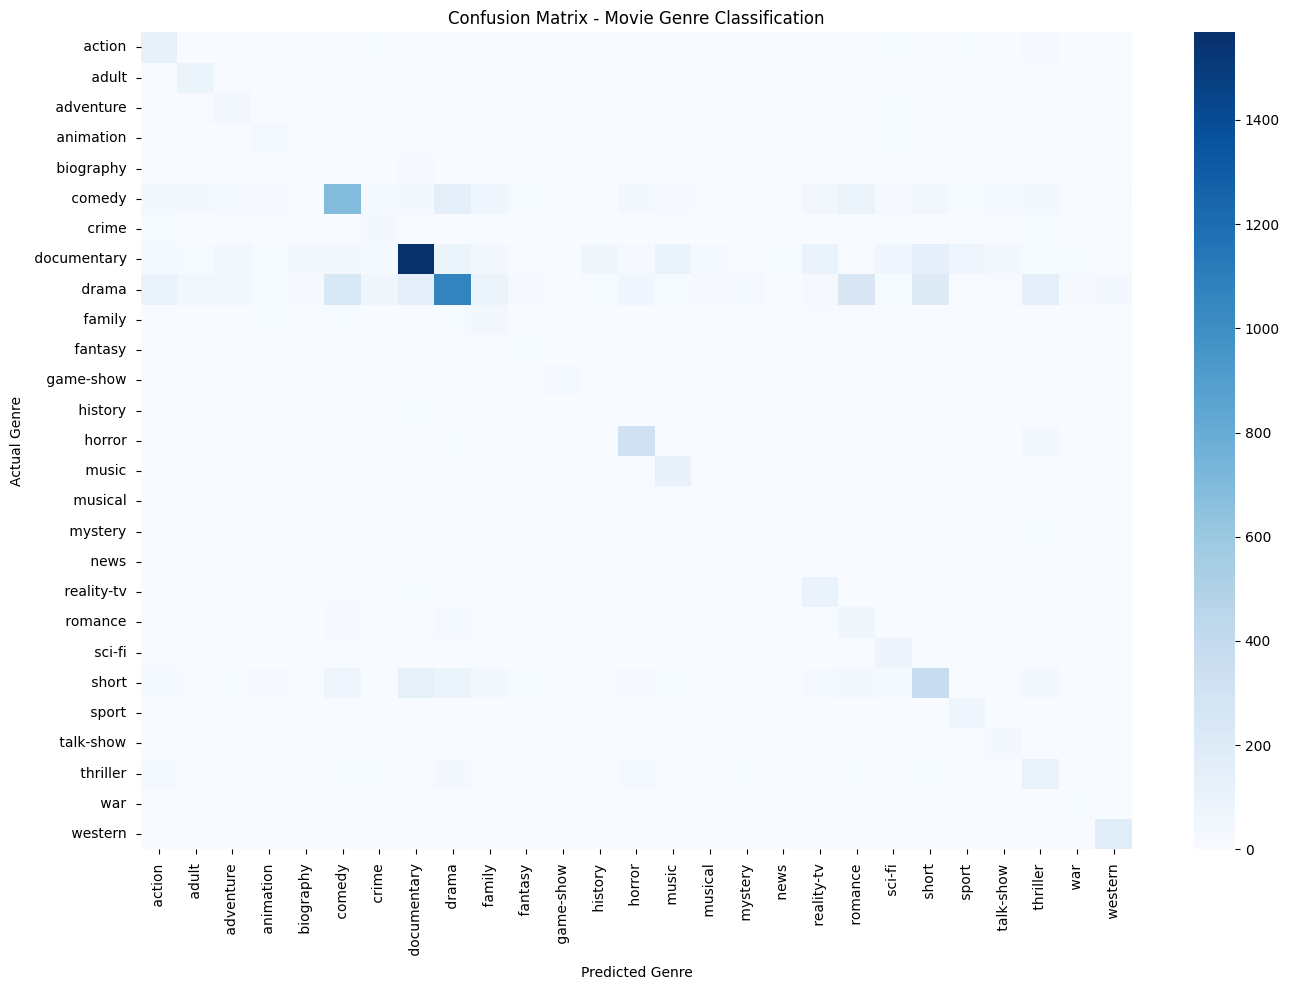

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=False,
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - Movie Genre Classification")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
sample_movies = [
    "A young detective investigates a mysterious murder and discovers a dangerous secret.",
    "A group of friends travel through space and fight an alien enemy.",
    "A family struggles to stay together while facing difficult emotional challenges.",
    "A terrifying creature attacks people in a small isolated town."
]

sample_tfidf = vectorizer.transform(sample_movies)

predictions = model.predict(sample_tfidf)

for movie, genre in zip(sample_movies, predictions):
    print("Movie Description:", movie)
    print("Predicted Genre:", genre)
    print("-" * 60)

Movie Description: A young detective investigates a mysterious murder and discovers a dangerous secret.
Predicted Genre:  mystery 
------------------------------------------------------------
Movie Description: A group of friends travel through space and fight an alien enemy.
Predicted Genre:  sci-fi 
------------------------------------------------------------
Movie Description: A family struggles to stay together while facing difficult emotional challenges.
Predicted Genre:  reality-tv 
------------------------------------------------------------
Movie Description: A terrifying creature attacks people in a small isolated town.
Predicted Genre:  horror 
------------------------------------------------------------


In [22]:
import joblib

joblib.dump(model, '/content/movie_genre_model.pkl')
joblib.dump(vectorizer, '/content/tfidf_vectorizer.pkl')

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
